In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import urllib.parse
import warnings
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SAWarning
from tqdm.auto import tqdm

from IPython import display

import random

import os
import joblib

D:\dev\conda_envs\lmsAI\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# ==========================================
# 1. MSSQL 데이터베이스 연결 및 데이터 로드
# ==========================================

warnings.filterwarnings("ignore", category=SAWarning)

COL = 'F03_01'

def load_data_from_mssql():

    try:
        server = "192.168.123.180"
        database = "kamtec"
        username = "sa"
        password = "cse"
        driver = "ODBC Driver 18 for SQL Server"
        
        params = urllib.parse.quote_plus(
            f"DRIVER={driver};"
            f"SERVER={server};"
            f"DATABASE={database};"
            f"UID={username};"
            f"PWD={password};"
            f"Encrypt=no;"
            f"TrustServerCertificate=yes;"
        )
        
        engine = create_engine(
            f"mssql+pyodbc:///?odbc_connect={params}",
            fast_executemany=True,
            pool_pre_ping=True,
            pool_recycle=3600
        )
    
        query = f"""
            SELECT s001, {COL}
            FROM kamtec.dbo.lmsCurrent_temp WITH (NOLOCK) 
            -- WHERE s001 >= '2026-01-22 10:20:00.0000000' AND s001 <= '2026-01-22 11:10:00.0000000' AND {COL} > 0
            -- WHERE id >= 80371892 AND id <= 80658474 AND {COL} > 0
             WHERE {COL} > 0
            ORDER BY id ASC
        """
    
        with engine.connect() as conn:
            df = pd.read_sql(text(query), conn)
        print("데이터 로드 성공! 총 데이터 수:", len(df))
        return df
    except Exception as e:
        print("DB 연결 또는 쿼리 실행 실패:", e)
        return None
        

df = load_data_from_mssql()

데이터 로드 성공! 총 데이터 수: 11120311


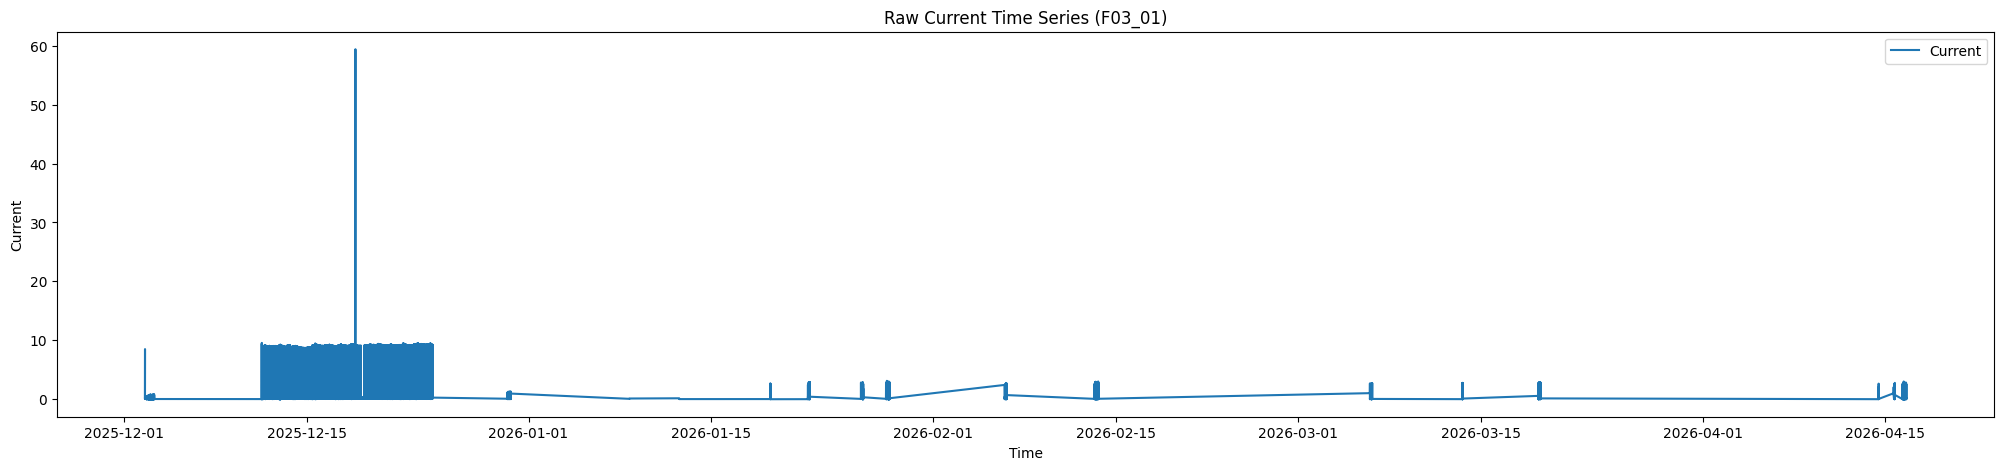

In [6]:
# ==========================================
# 1-1. 전체 데이터 시각화
# ==========================================

plt.figure(figsize=(25, 5))

plt.plot(df["s001"], df[COL], label="Current")

plt.title(f"Raw Current Time Series ({COL})")
plt.xlabel("Time")
plt.ylabel("Current")
plt.legend()

plt.show()

In [203]:
# ==========================================
# 2. 스케일링
# ==========================================

scaler = MinMaxScaler()
df["scaled"] = scaler.fit_transform(df[[COL]])

In [204]:
# ==========================================
# 3. 스파이크 시퀀스 추출 
# ==========================================

def extract_rising_start_sequences(
    signal,
    seq_len=20,
    pre_offset=2,
    slope_factor=3.0,
    min_peak=0.5
):
    signal = np.asarray(signal)
    
    # 🔥 1. 미리 diff 계산
    diff = np.diff(signal)
    
    # 🔥 2. slope threshold
    slope_th = diff.mean() + slope_factor * diff.std()
    
    # 🔥 3. 상승 시작점 후보 (벡터화)
    rising_points = np.where(
        (diff[:-1] <= 0) &
        (diff[1:] > slope_th)
    )[0] + 1
    
    sequences = []
    last_idx = -seq_len
    
    for i in rising_points:
        
        # 🔥 중복 제거 먼저 (빠르게 컷)
        if i - last_idx < seq_len:
            continue
        
        start = i - pre_offset
        end = start + seq_len
        
        if start < 0 or end > len(signal):
            continue
        
        seq = signal[start:end]
        
        # 🔥 필요한 것만 최소 계산
        peak = seq.max()
        if peak < min_peak:
            continue
        
        # 🔥 diff도 미리 슬라이스
        seq_diff = diff[start:end-1]
        rise_speed = seq_diff.max()
        
        if rise_speed <= 0.15:
            continue
        
        peak_idx = np.argmax(seq)
        cond_position = pre_offset <= peak_idx <= (pre_offset + 4)
        if not cond_position:
            continue
        
        sequences.append(seq)
        last_idx = i
    
    return np.array(sequences)

SEQ_LEN = 20

all_sequences = extract_rising_start_sequences(
    df["scaled"].values,
    seq_len=SEQ_LEN,
    pre_offset=4,
    slope_factor=3.0,
    min_peak=0.4
)

print("스파이크 개수:", len(all_sequences))

스파이크 개수: 3002


In [205]:
def extract_sharp_rise_sequences(
    signal,
    seq_len=20,
    pre_offset=5,
    slope_factor=3.0,     # 🔥 민감도 (높을수록 엄격)
    min_jump=0.2,         # 🔥 절대 상승량 기준
    dedup_gap=10          # 🔥 중복 제거
):
    signal = np.asarray(signal)
    diff = np.diff(signal)

    # 🔥 1. 통계 기반 threshold
    slope_th = diff.mean() + slope_factor * diff.std()

    # 🔥 2. 급상승 조건 (두 가지 동시에 만족)
    rise_points = np.where(
        (diff > slope_th) &      # 통계적으로 큼
        (diff > min_jump)        # 절대값도 큼
    )[0] + 1

    sequences = []
    indices = []

    last_idx = -dedup_gap

    for i in rise_points:

        # 🔥 3. 중복 제거 (같은 이벤트 여러번 잡는거 방지)
        if i - last_idx < dedup_gap:
            continue

        start = i - pre_offset
        end = start + seq_len

        if start < 0 or end > len(signal):
            continue

        seq = signal[start:end]

        # 🔥 4. 진짜 "상승"인지 확인 (앞뒤 평균 비교)
        before = np.mean(signal[max(0, i-5):i])
        after = np.mean(signal[i:i+5])

        if (after - before) < min_jump:
            continue

        sequences.append(seq)
        indices.append(i)
        last_idx = i

    return np.array(sequences), np.array(indices)

SEQ_LEN = 20

all_sequences, indices = extract_sharp_rise_sequences(
    df["scaled"].values,
    seq_len=SEQ_LEN,
    pre_offset=5,
    slope_factor=3.0,     
    min_jump=0.3,         
    dedup_gap=10         
)

print("스파이크 개수:", len(all_sequences))
# print("발생 위치:", indices)

스파이크 개수: 2516


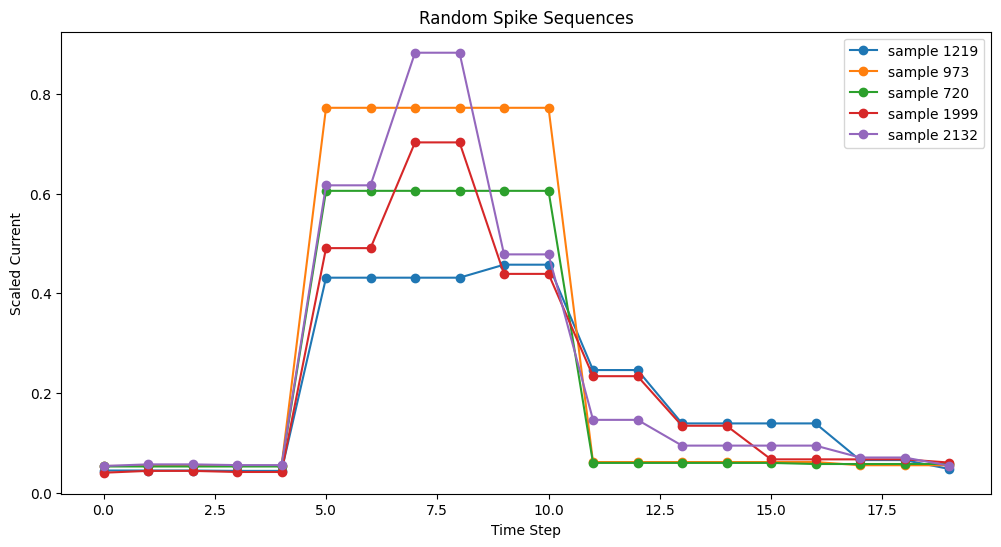

In [206]:
# ==========================================
# 3-1. 스파이크 전류 스케일 데이터 시각화
# ==========================================

def plot_random_sequences(sequences, num_samples=5):
    plt.figure(figsize=(12, 6))
    
    for i in range(num_samples):
        idx = random.randint(0, len(sequences)-1)
        seq = sequences[idx]
        
        plt.plot(seq, marker='o', label=f"sample {idx}")
    
    plt.title("Random Spike Sequences")
    plt.xlabel("Time Step")
    plt.ylabel("Scaled Current")
    plt.legend()
    plt.show()

plot_random_sequences(all_sequences, 5)

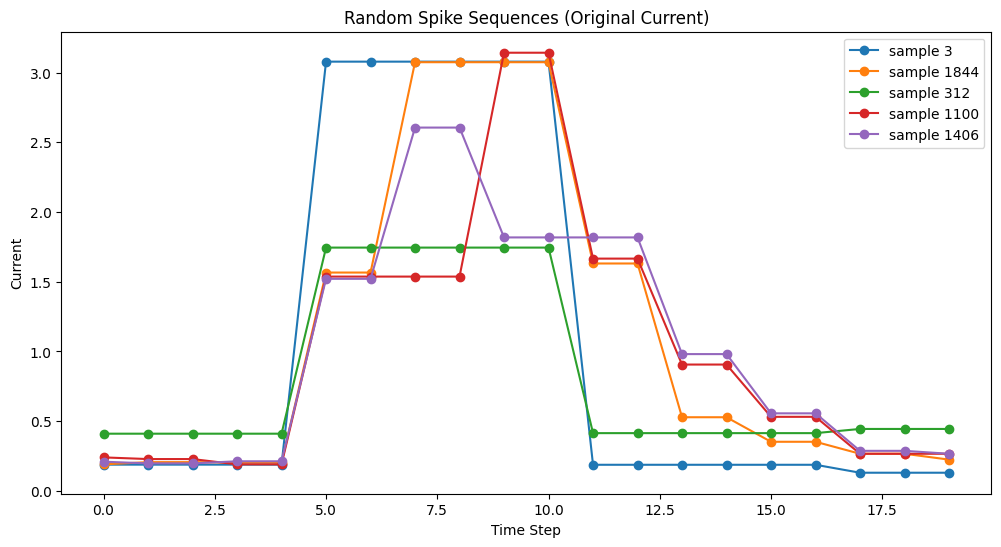

In [207]:
# ==========================================
# 3-2. 스파이크 전류 원본 데이터 시각화
# ==========================================

def plot_random_sequences_original(sequences, scaler, num_samples=5):
    plt.figure(figsize=(12, 6))
    
    for i in range(num_samples):
        idx = random.randint(0, len(sequences)-1)
        seq = sequences[idx]
        
        # 🔥 역정규화
        seq_original = scaler.inverse_transform(seq.reshape(-1, 1)).flatten()
        
        plt.plot(seq_original, marker='o', label=f"sample {idx}")
    
    plt.title("Random Spike Sequences (Original Current)")
    plt.xlabel("Time Step")
    plt.ylabel("Current")
    plt.legend()
    plt.show()

plot_random_sequences_original(all_sequences, scaler, 5)

In [208]:
# ==========================================
# 4. Train / Test 분리
# ==========================================

train_sequences, test_sequences = train_test_split(
    all_sequences,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(train_sequences.shape, test_sequences.shape)

(2012, 20) (504, 20)


In [209]:
# ==========================================
# 5. Tensor 변환
# ==========================================

BATCH_SIZE = 128

X_train = torch.tensor(train_sequences, dtype=torch.float32).unsqueeze(-1)
X_test = torch.tensor(test_sequences, dtype=torch.float32).unsqueeze(-1)

train_dataset = TensorDataset(X_train, X_train)
test_dataset = TensorDataset(X_test, X_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [210]:
# ==========================================
# 6. LSTM Autoencoder
# ==========================================

class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super().__init__()
        
        self.seq_len = seq_len
        
        self.encoder = nn.LSTM(
            n_features, embedding_dim,
            num_layers=2, batch_first=True, dropout=0.2
        )
        
        self.decoder = nn.LSTM(
            embedding_dim, embedding_dim,
            num_layers=2, batch_first=True, dropout=0.2
        )
        
        self.output_layer = nn.Linear(embedding_dim, n_features)
    
    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        hidden = hidden[-1]
        
        hidden = hidden.unsqueeze(1).repeat(1, self.seq_len, 1)
        
        decoded, _ = self.decoder(hidden)
        out = self.output_layer(decoded)
        
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMAutoencoder(SEQ_LEN, 1).to(device)

criterion = nn.HuberLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [211]:
# ==========================================
# 7. 학습
# ==========================================

EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    losses = []
    
    for batch_x, _ in tqdm(train_loader):
        batch_x = batch_x.to(device)
        
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_x)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    print(f"Epoch {epoch+1} Loss:", np.mean(losses))

100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 68.23it/s]


Epoch 1 Loss: 0.03721358301118016


100%|█████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 296.29it/s]


Epoch 2 Loss: 0.03241673670709133


100%|█████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 301.88it/s]


...

Epoch 98 Loss: 0.0031700865365564823


100%|█████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 313.72it/s]


Epoch 99 Loss: 0.0031231950561050326


100%|█████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 316.74it/s]

Epoch 100 Loss: 0.003068252422963269


In [212]:
# ==========================================
# 8. Threshold 계산
# ==========================================

def get_errors(model, loader):
    model.eval()
    errors = []
    
    with torch.no_grad():
        for batch_x, _ in loader:
            batch_x = batch_x.to(device)
            output = model(batch_x)
            
            loss = torch.mean((batch_x - output) ** 2, dim=(1,2))
            errors.extend(loss.cpu().numpy())
    
    return np.array(errors)

train_errors = get_errors(model, train_loader)

threshold = np.percentile(train_errors, 99.5)

print("Threshold:", threshold)

Threshold: 0.021467339852824785


In [213]:
# ==========================================
# 9. 테스트 이상 탐지
# ==========================================

test_errors = get_errors(model, test_loader)

anomalies = test_errors > threshold

print("이상 개수:", np.sum(anomalies))

이상 개수: 8


In [214]:
anomaly_indices = np.where(anomalies)[0]
print("이상 인덱스:", anomaly_indices[:10])

이상 인덱스: [ 78 186 190 239 241 374 441 502]


In [215]:
signal_scaled = df["scaled"].values
signal_raw = df[COL].values

def find_sequence_index(signal_scaled, seq):
    for i in range(len(signal_scaled) - len(seq)):
        if np.allclose(signal_scaled[i:i+len(seq)], seq):
            return i
    return None

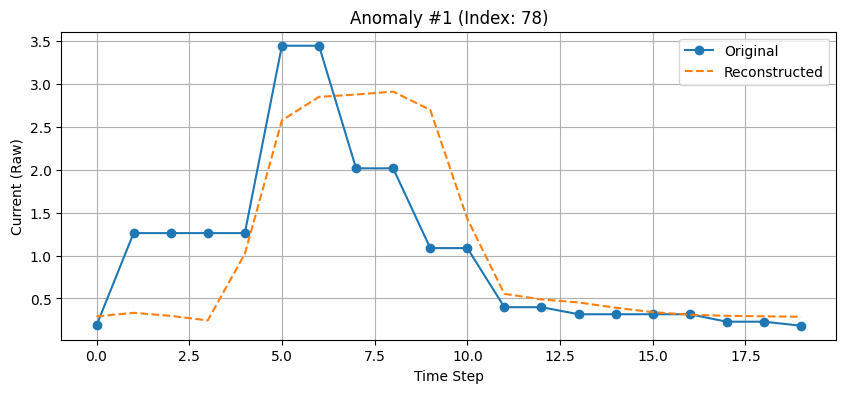

original: [0.184     1.262     1.262     1.262     1.262     3.4490001 3.4490001
 2.018     2.018     1.087     1.087     0.397     0.397     0.315
 0.315     0.315     0.315     0.228     0.228     0.181    ]
reconstructed: [0.28942713 0.33139554 0.29638603 0.2427482  1.019935   2.5779424
 2.8521144  2.8792288  2.9133809  2.6996782  1.4288524  0.5528555
 0.48778573 0.45266265 0.39107093 0.33940053 0.3096463  0.29647556
 0.29088435 0.28565976]


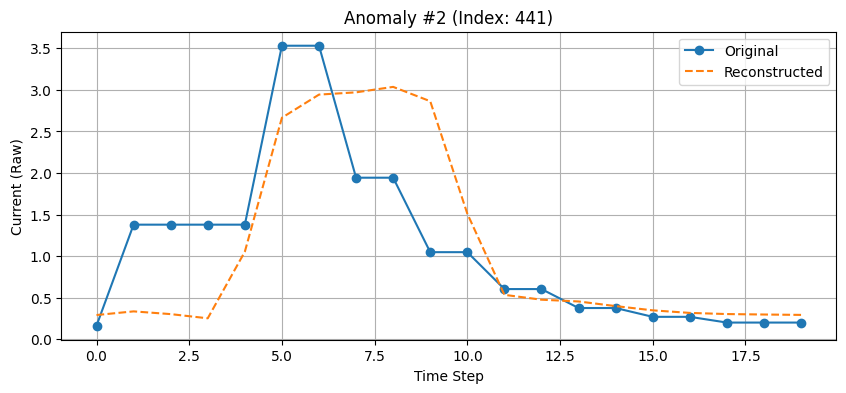

original: [0.16199999 1.3779999  1.3779999  1.3779999  1.3779999  3.5310001
 3.5310001  1.943      1.943      1.047      1.047      0.603
 0.603      0.37500003 0.37500003 0.269      0.269      0.19999999
 0.19999999 0.19999999]
reconstructed: [0.2906323  0.3345739  0.3017302  0.25132048 1.0524613  2.6644542
 2.9429588  2.9700391  3.0357237  2.8632402  1.5100831  0.53364944
 0.47510436 0.45385405 0.39808434 0.34706783 0.3162088  0.30237693
 0.296811   0.29223174]


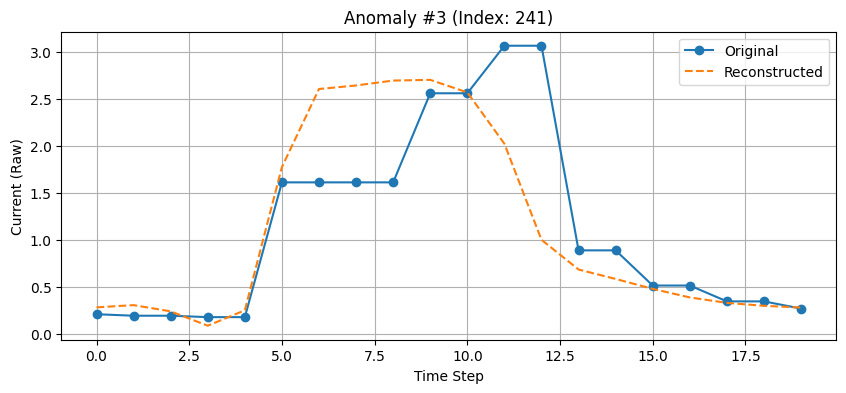

original: [0.206      0.18999998 0.18999998 0.175      0.175      1.612
 1.612      1.612      1.612      2.562      2.562      3.069
 3.069      0.887      0.887      0.51199996 0.51199996 0.343
 0.343      0.266     ]
reconstructed: [0.2791426  0.3029771  0.23650081 0.08338802 0.2480325  1.774926
 2.6073139  2.6452637  2.6975756  2.705042   2.5711477  2.0239084
 0.999659   0.6825503  0.58207905 0.47619364 0.38500655 0.32693174
 0.29573247 0.27693623]


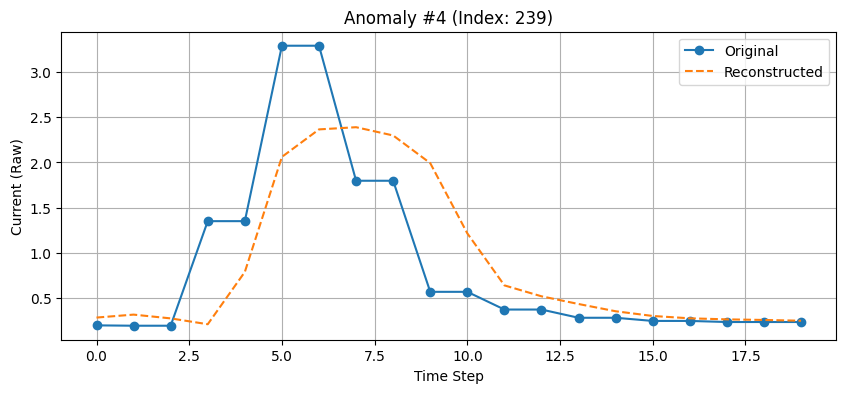

original: [0.197      0.193      0.193      1.3499999  1.3499999  3.291
 3.291      1.7969999  1.7969999  0.568      0.568      0.372
 0.372      0.28100002 0.28100002 0.24599999 0.24599999 0.234
 0.234      0.234     ]
reconstructed: [0.28319585 0.3159077  0.27409625 0.20942275 0.78798324 2.0609612
 2.3652127  2.3894053  2.2979991  1.9918739  1.2148659  0.6393824
 0.51849157 0.43320847 0.35301217 0.30088046 0.27493343 0.2633742
 0.25680938 0.24820857]


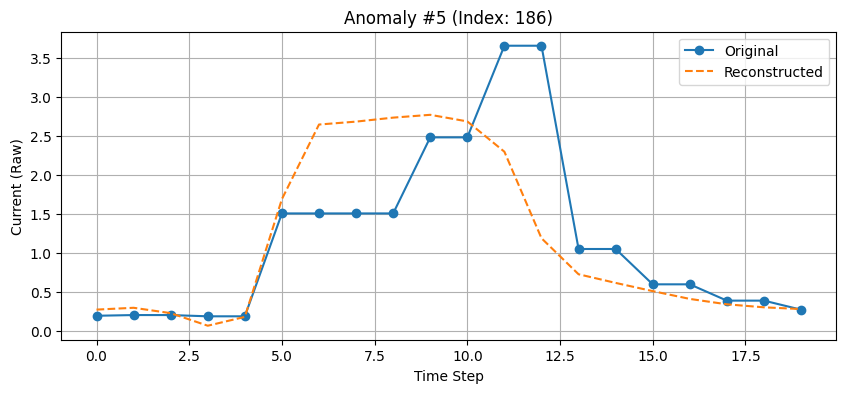

original: [0.19999999 0.20899999 0.20899999 0.193      0.193      1.5119998
 1.5119998  1.5119998  1.5119998  2.487      2.487      3.6620002
 3.6620002  1.056      1.056      0.603      0.603      0.394
 0.394      0.278     ]
reconstructed: [0.27891803 0.302272   0.23348047 0.07231921 0.18555342 1.6956182
 2.6515846  2.6890328  2.7401552  2.7762258  2.691518   2.3029618
 1.1938965  0.7320487  0.62126476 0.5159278  0.41597927 0.34679833
 0.30826315 0.28590542]


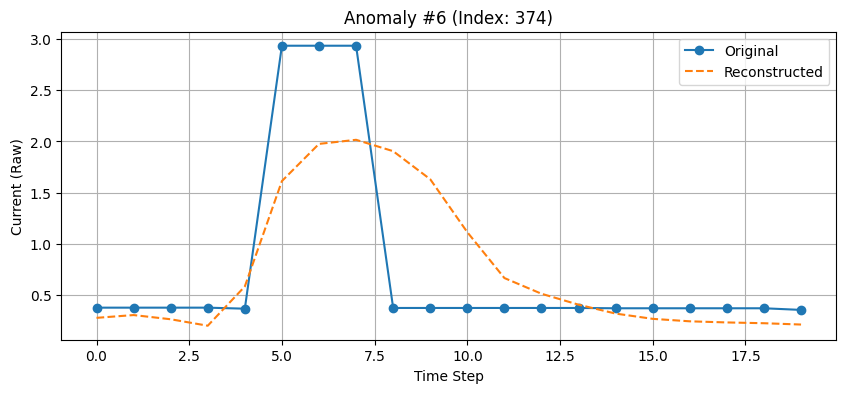

original: [0.378      0.378      0.378      0.378      0.368      2.934
 2.934      2.934      0.37500003 0.37500003 0.37500003 0.37500003
 0.37500003 0.37500003 0.372      0.372      0.372      0.372
 0.372      0.35600004]
reconstructed: [0.27851242 0.30572867 0.2647447  0.20170242 0.58499914 1.6133512
 1.9761254  2.0159318  1.9050378  1.6308625  1.1142455  0.6669266
 0.51374155 0.40700123 0.32009974 0.26878107 0.24468508 0.23376179
 0.22606976 0.2132141 ]


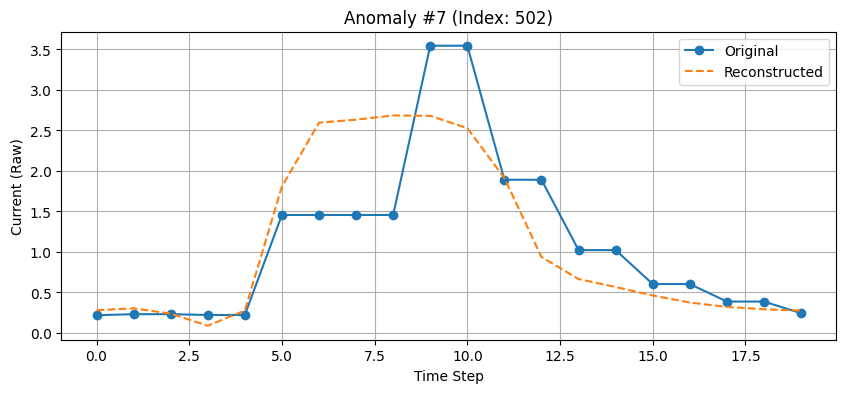

original: [0.218      0.23099999 0.23099999 0.221      0.221      1.456
 1.456      1.456      1.456      3.5460002  3.5460002  1.891
 1.891      1.022      1.022      0.603      0.603      0.387
 0.387      0.243     ]
reconstructed: [0.27931592 0.3034949  0.2380705  0.08841665 0.27536651 1.8072706
 2.5952969  2.6331587  2.684463   2.6802855  2.52798    1.912502
 0.9369178  0.66484725 0.5667165  0.46183518 0.374617   0.32066745
 0.29198125 0.27436817]


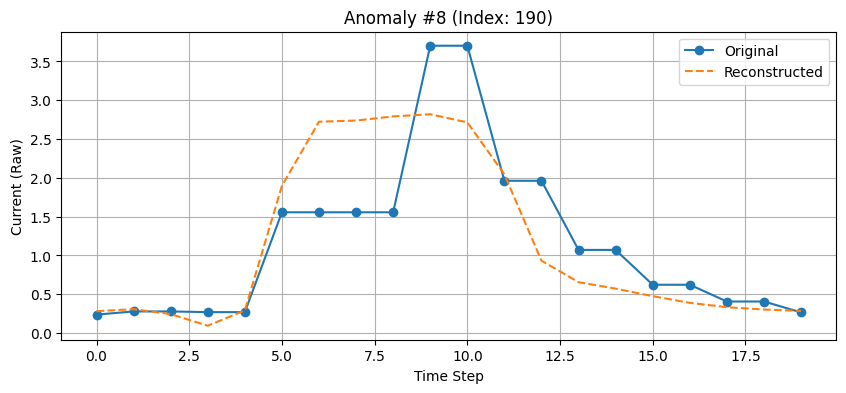

original: [0.23699999 0.278      0.278      0.269      0.269      1.5559999
 1.5559999  1.5559999  1.5559999  3.703      3.703      1.9619999
 1.9619999  1.071      1.071      0.622      0.622      0.40600002
 0.40600002 0.266     ]
reconstructed: [0.28088126 0.30736396 0.24333416 0.09383891 0.29107612 1.8963333
 2.723449   2.7384696  2.791724   2.8200078  2.7144542  2.0448651
 0.93200684 0.655046   0.57191193 0.47456318 0.38842583 0.33265638
 0.30254933 0.28442737]


In [216]:
def plot_anomaly_with_reconstruction(
    model,
    test_sequences,
    anomaly_indices,
    num_samples=5
):
    model.eval()
    
    if len(anomaly_indices) == 0:
        print("이상 없음")
        return
    
    selected = random.sample(
        list(anomaly_indices),
        min(num_samples, len(anomaly_indices))
    )
    
    for i, idx in enumerate(selected):
        seq_scaled = test_sequences[idx]
        
        # 🔥 모델 입력
        input_tensor = torch.tensor(seq_scaled, dtype=torch.float32)\
            .unsqueeze(0).unsqueeze(-1).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
        
        # 🔥 numpy 변환
        input_seq = input_tensor.squeeze().cpu().numpy()
        output_seq = output.squeeze().cpu().numpy()
        
        # 🔥 원본 전류로 복원
        input_raw = scaler.inverse_transform(input_seq.reshape(-1,1)).flatten()
        output_raw = scaler.inverse_transform(output_seq.reshape(-1,1)).flatten()
        
        # 🔥 👉 그래프를 매번 새로 생성
        plt.figure(figsize=(10, 4))
        
        plt.plot(input_raw, marker='o', label="Original")
        plt.plot(output_raw, linestyle='--', label="Reconstructed")
        
        plt.title(f"Anomaly #{i+1} (Index: {idx})")
        plt.xlabel("Time Step")
        plt.ylabel("Current (Raw)")
        plt.legend()
        plt.grid(True)
        
        plt.show()

        print(f'original: {input_raw}')
        print(f'reconstructed: {output_raw}')

plot_anomaly_with_reconstruction(model, test_sequences, anomaly_indices, num_samples=10)

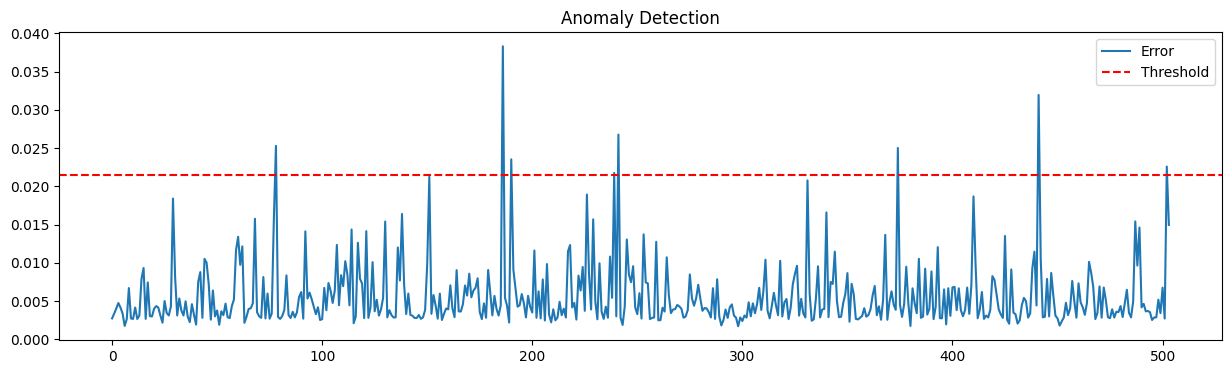

In [217]:
# ==========================================
# 10. 시각화
# ==========================================

plt.figure(figsize=(15,4))
plt.plot(test_errors, label="Error")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold")
plt.legend()
plt.title("Anomaly Detection")
plt.show()

In [218]:
SAVE_DIR = f"./model/{COL}"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. 모델 저장
torch.save(model.state_dict(), f"{SAVE_DIR}/model.pth")

# 2. 스케일러 저장
joblib.dump(scaler, f"{SAVE_DIR}/scaler.pkl")

# 3. threshold 저장
np.save(f"{SAVE_DIR}/threshold.npy", threshold)

print(f"모델 저장 완료 → {SAVE_DIR}")

모델 저장 완료 → ./model/F03_06
